In [ ]:
!pip install folium pandas numpy

In [ ]:
import folium
import pandas as pd
import numpy as np

# -------------------------------
# 1. Load AQI data
# -------------------------------
data = pd.read_csv("SAMPLE DATA.csv")

# -------------------------------
# 2. Define city boundaries
# (change according to your city)
# -------------------------------
LAT_MIN, LAT_MAX = 17.3800, 17.3900
LON_MIN, LON_MAX = 78.4800, 78.4900

# Grid size (approx 500m)
GRID_SIZE = 0.0025

# -------------------------------
# 3. Assign Grid IDs
# -------------------------------
data["grid_x"] = ((data["lat"] - LAT_MIN) / GRID_SIZE).astype(int)
data["grid_y"] = ((data["lon"] - LON_MIN) / GRID_SIZE).astype(int)

# -------------------------------
# 4. Compute Grid-Level AQI
# -------------------------------
grid_aqi = (
    data.groupby(["grid_x", "grid_y"])["aqi"]
    .mean()
    .reset_index()
)

# -------------------------------
# 5. AQI → Color mapping
# -------------------------------
def aqi_color(aqi):
    if aqi <= 50:
        return "green"
    elif aqi <= 100:
        return "yellow"
    elif aqi <= 200:
        return "orange"
    elif aqi <= 300:
        return "red"
    else:
        return "purple"

# -------------------------------
# 6. Create Map
# -------------------------------
map_center = [data["lat"].mean(), data["lon"].mean()]
m = folium.Map(location=map_center, zoom_start=14)

# -------------------------------
# 7. Draw Grid Squares
# -------------------------------
for _, row in grid_aqi.iterrows():
    lat_start = LAT_MIN + row["grid_x"] * GRID_SIZE
    lon_start = LON_MIN + row["grid_y"] * GRID_SIZE

    lat_end = lat_start + GRID_SIZE
    lon_end = lon_start + GRID_SIZE

    folium.Rectangle(
        bounds=[(lat_start, lon_start), (lat_end, lon_end)],
        color=None,
        fill=True,
        fill_color=aqi_color(row["aqi"]),
        fill_opacity=0.6,
        popup=f"Avg AQI: {row['aqi']:.2f}"
    ).add_to(m)

# -------------------------------
# 8. Save Heatmap
# -------------------------------
m.save("grid_aqi_heatmap.html")

print("✅ Grid-based AQI heatmap created successfully!")

✅ Grid-based AQI heatmap created successfully!


In [ ]:
from IPython.display import display
display(m)

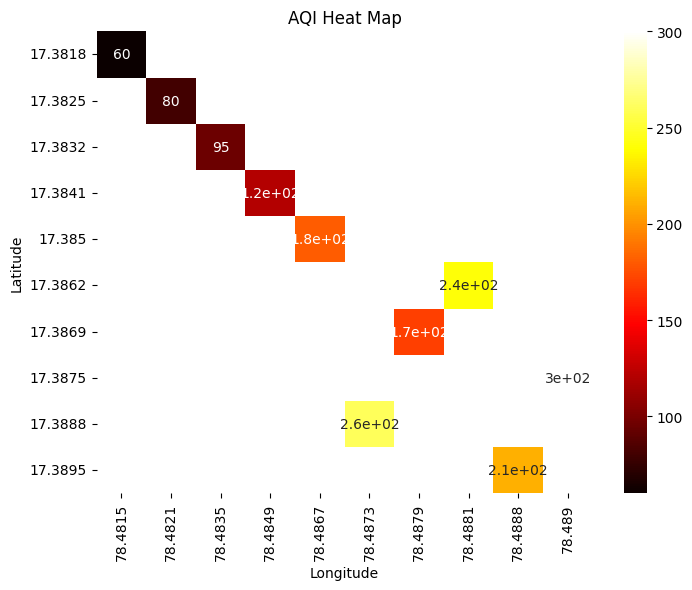

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("SAMPLE DATA.csv")

# Convert data into heatmap format
heatmap_data = df.pivot_table(
    values="aqi",
    index="lat",
    columns="lon"
)

# Plot heat map
plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, cmap="hot")
plt.title("AQI Heat Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
